<a href="https://colab.research.google.com/github/ai7dnn/2026-1-BDA/blob/main/code/13w_appendix_airquality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 그룹화와 결측처리

In [ ]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 44.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=5a3588a0b1323aff1acdf1d5fb151084193623ba67c740b0c23141a0f9f9a873
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 45.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.precision', 2)

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

In [ ]:
from IPython.display import display_html
import inspect
import ast

def display_side_by_side(*dfs):
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(dfs)

    if len(titles) < len(dfs):
        titles += [''] * (len(dfs) - len(titles))

    html_str = ''
    for df, title in zip(dfs, titles):
        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {df.to_html()}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

In [ ]:
from IPython.display import display_html
import inspect
import ast

def display_series_side_by_side(*args):
    """여러 Series를 옆으로 나란히 표시하고,
    호출 시 사용한 표현식을 제목으로 위에 출력한다.
    """
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(args)

    if len(titles) < len(args):
        titles += [''] * (len(args) - len(titles))

    html_str = ''
    for s, title in zip(args, titles):
        table_html = s.to_frame().to_html()

        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {table_html}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

In [ ]:
from pydataset import data

df = data('airquality')
display_side_by_side(df.head(), df.tail())

initiated datasets repo at: /root/.pydataset/


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5
,Ozone,Solar.R,Wind,Temp,Month,Day
149,30.0,193.0,6.9,70,9,26
150,NaN,145.0,13.2,77,9,27
151,14.0,191.0,14.3,75,9,28
152,18.0,131.0,8.0,76,9,29


In [ ]:
import pandas as pd

s1 = pd.Series([1, 2, 3], index=['a','b','c'], name='점수')
s2 = pd.Series([10, 20], index=['x','y'], name='등급')
s3 = pd.Series(['A','B','C','D'], name='학점')

# Series.name 자동 사용
display_series_side_by_side(s1, s2, s3)

,점수
a,1
b,2
c,3
,등급
x,10
y,20
,학점
0,A
1,B
2,C


In [ ]:
from pydataset import data

df = data('airquality')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 8.4 KB


In [ ]:
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.00,190.00,7.40,67,5,1
2,36.00,118.00,8.00,72,5,2
3,12.00,149.00,12.60,74,5,3
4,18.00,313.00,11.50,62,5,4
5,NaN,NaN,14.30,56,5,5


In [ ]:
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.00,146.00,153.00,153.00,153.00,153.00
mean,42.13,185.93,9.96,77.88,6.99,15.80
std,32.99,90.06,3.52,9.47,1.42,8.86
min,1.00,7.00,1.70,56.00,5.00,1.00
25%,18.00,115.75,7.40,72.00,6.00,8.00
50%,31.50,205.00,9.70,79.00,7.00,16.00
75%,63.25,258.75,11.50,85.00,8.00,23.00
max,168.00,334.00,20.70,97.00,9.00,31.00


In [ ]:
df = data('airquality')
display_side_by_side(df.head(), df.tail())

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.00,190.00,7.40,67,5,1
2,36.00,118.00,8.00,72,5,2
3,12.00,149.00,12.60,74,5,3
4,18.00,313.00,11.50,62,5,4
5,NaN,NaN,14.30,56,5,5
,Ozone,Solar.R,Wind,Temp,Month,Day
149,30.00,193.00,6.90,70,9,26
150,NaN,145.00,13.20,77,9,27
151,14.00,191.00,14.30,75,9,28
152,18.00,131.00,8.00,76,9,29


In [ ]:
display_series_side_by_side(df.isnull().sum(), df.isna().sum())

,0
Ozone,37
Solar.R,7
Wind,0
Temp,0
Month,0
Day,0
,0
Ozone,37
Solar.R,7
Wind,0


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5, 3)

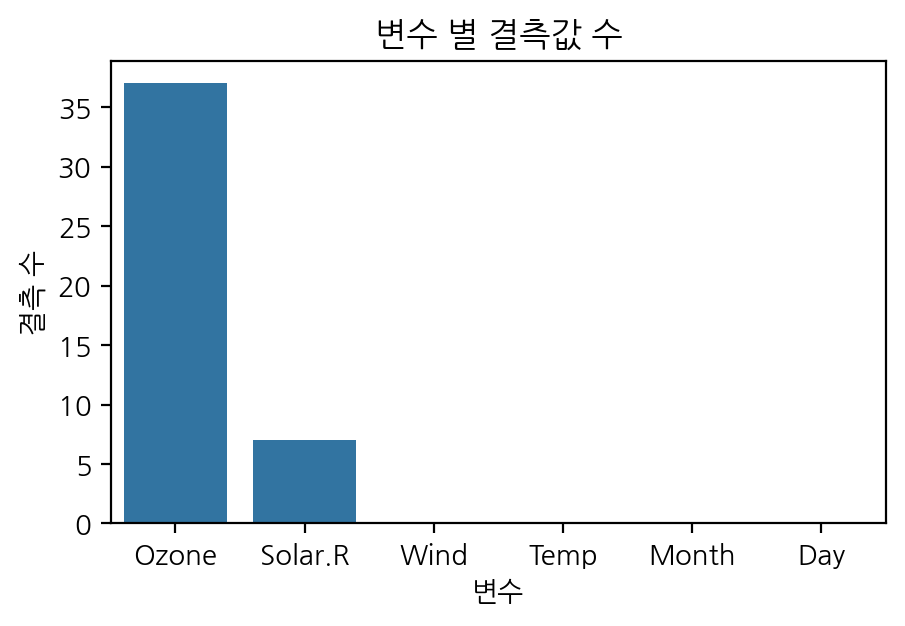

In [ ]:
import seaborn as sns

plt.title('변수 별 결측값 수')
sns.barplot(df.isnull().sum())
plt.ylabel('결측 수')
plt.xlabel('변수')
plt.show()

In [ ]:
df[df.Ozone.isnull()]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
10,NaN,194.00,8.60,69,5,10
25,NaN,66.00,16.60,57,5,25
26,NaN,266.00,14.90,58,5,26
27,NaN,NaN,8.00,57,5,27
32,NaN,286.00,8.60,78,6,1
33,NaN,287.00,9.70,74,6,2
34,NaN,242.00,16.10,67,6,3
35,NaN,186.00,9.20,84,6,4
36,NaN,220.00,8.60,85,6,5


In [ ]:
display_side_by_side(df[df.Ozone.isnull()], df[df['Solar.R'].isnull()])

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
10,NaN,194.00,8.60,69,5,10
25,NaN,66.00,16.60,57,5,25
26,NaN,266.00,14.90,58,5,26
27,NaN,NaN,8.00,57,5,27
32,NaN,286.00,8.60,78,6,1
33,NaN,287.00,9.70,74,6,2
34,NaN,242.00,16.10,67,6,3
35,NaN,186.00,9.20,84,6,4
36,NaN,220.00,8.60,85,6,5


In [ ]:
df[ (df.Ozone.isnull()) & (df['Solar.R'].isnull()) ]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
27,NaN,NaN,8.00,57,5,27


## 그룹화 groupby()

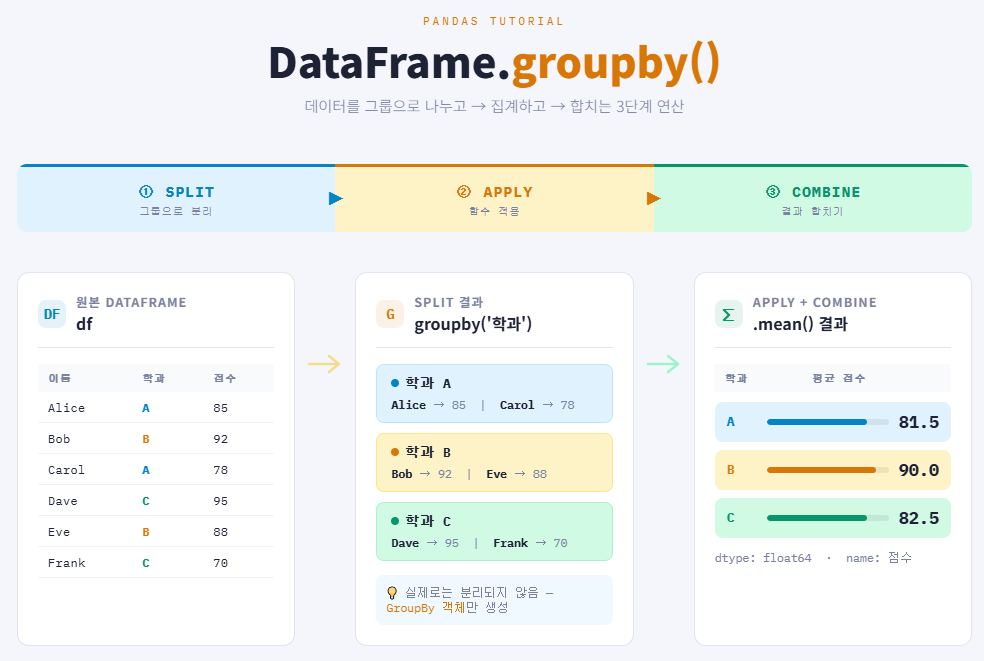

In [ ]:
import pandas as pd

df = pd.DataFrame({
    '이름': ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank'],
    '학과': ['A', 'B', 'A', 'C', 'B', 'C'],
    '학년': [1, 2, 2, 1, 1, 3],
    '점수': [85, 92, 78, 95, 88, 70]
})
df

,이름,학과,학년,점수
0,Alice,A,1,85
1,Bob,B,2,92
2,Carol,A,2,78
3,Dave,C,1,95
4,Eve,B,1,88
5,Frank,C,3,70


In [ ]:
# ① 기본: 학과별 평균
df.groupby('학과')['점수'].mean()

,점수
학과,
A,81.50
B,90.00
C,82.50


In [ ]:
# ② 여러 집계 함수 동시 적용
df.groupby('학과')['점수'].agg(['mean', 'max', 'count', 'std'])

,mean,max,count,std
학과,,,,
A,81.50,85,2,4.95
B,90.00,92,2,2.83
C,82.50,95,2,17.68


In [ ]:
# ③ 여러 컬럼으로 groupby (다중 키)
df.groupby(['학과', '학년'])['점수'].mean()

학과  학년
A   1    85.00
    2    78.00
B   1    88.00
    2    92.00
C   1    95.00
    3    70.00
Name: 점수, dtype: float64

In [ ]:
# ④ transform: 원본 크기 유지 (핵심 차이!)
df['학과평균'] = df.groupby('학과')['점수'].transform('mean')
df

,이름,학과,학년,점수,학과평균
0,Alice,A,1,85,81.50
1,Bob,B,2,92,90.00
2,Carol,A,2,78,81.50
3,Dave,C,1,95,82.50
4,Eve,B,1,88,90.00
5,Frank,C,3,70,82.50


In [ ]:
df.groupby('학과')['점수'].mean()

,점수
학과,
A,81.50
B,90.00
C,82.50


### groupby()
#### ① df.groupby('Month')
- Month 컬럼의 고유값을 기준으로 행을 묶음
- 반환 타입: DataFrameGroupBy 객체 (아직 연산 없음, lazy evaluation)

#### ② ['Ozone']
- GroupBy 객체에서 Ozone 컬럼만 선택
- 반환 타입: DataFrameGroupBy → SeriesGroupBy

In [ ]:
from pydataset import data

df = data('airquality')
df.groupby('Month')['Ozone']

### DataFrameGroupBy or SeriesGroupBy의 속성 groups
#### ③ .groups
- 각 그룹 키 → 해당 그룹에 속하는 인덱스 레이블 목록을 매핑한 딕셔너리 반환
- 반환 타입: dict

In [ ]:
df.groupby('Month')['Ozone'].groups

{5: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], 6: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], 7: [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92], 8: [93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123], 9: [124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153]}

In [ ]:
# 그룹 키(Month 고유값) 목록 확인
df.groupby('Month')['Ozone'].groups.keys()

dict_keys([5, 6, 7, 8, 9])

In [ ]:
# 그룹 키(Month 고유값) 목록 확인
df.groupby('Month')['Ozone'].groups.values()

dict_values([Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64'), Index([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61],
      dtype='int64'), Index([62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
       80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92],
      dtype='int64'), Index([ 93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123],
      dtype='int64'), Index([124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153],
      dtype='int64')])

In [ ]:
# 그룹 키(Month 고유값) 목록 확인
df.groupby('Month')['Ozone'].groups.items()

dict_items([(5, Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')), (6, Index([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61],
      dtype='int64')), (7, Index([62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
       80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92],
      dtype='int64')), (8, Index([ 93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123],
      dtype='int64')), (9, Index([124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153],
      dtype='int64'))])

In [ ]:
df.groupby('Month')['Ozone'].groups[5] # 5월의 오존 값이 있는 첨자

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')

In [ ]:
df.groupby('Month')['Ozone'].groups[9] # 9월의 오존 값이 있는 첨자

Index([124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153],
      dtype='int64')

In [ ]:
# 5월의 데이터
df.loc[ df.groupby('Month')['Ozone'].groups[5] ]

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.00,190.00,7.40,67,5,1
2,36.00,118.00,8.00,72,5,2
3,12.00,149.00,12.60,74,5,3
4,18.00,313.00,11.50,62,5,4
5,NaN,NaN,14.30,56,5,5
6,28.00,NaN,14.90,66,5,6
7,23.00,299.00,8.60,65,5,7
8,19.00,99.00,13.80,59,5,8
9,8.00,19.00,20.10,61,5,9
10,NaN,194.00,8.60,69,5,10


In [ ]:
df.groupby('Month').groups

{5: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], 6: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], 7: [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92], 8: [93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123], 9: [124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153]}

In [ ]:
# 5월의 데이터
df.loc[ df.groupby('Month').groups[5] ]

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.00,190.00,7.40,67,5,1
2,36.00,118.00,8.00,72,5,2
3,12.00,149.00,12.60,74,5,3
4,18.00,313.00,11.50,62,5,4
5,NaN,NaN,14.30,56,5,5
6,28.00,NaN,14.90,66,5,6
7,23.00,299.00,8.60,65,5,7
8,19.00,99.00,13.80,59,5,8
9,8.00,19.00,20.10,61,5,9
10,NaN,194.00,8.60,69,5,10


In [ ]:
# 5월의 데이터
df[df.Month == 5]

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.00,190.00,7.40,67,5,1
2,36.00,118.00,8.00,72,5,2
3,12.00,149.00,12.60,74,5,3
4,18.00,313.00,11.50,62,5,4
5,NaN,NaN,14.30,56,5,5
6,28.00,NaN,14.90,66,5,6
7,23.00,299.00,8.60,65,5,7
8,19.00,99.00,13.80,59,5,8
9,8.00,19.00,20.10,61,5,9
10,NaN,194.00,8.60,69,5,10


In [ ]:
df.groupby('Month')['Ozone'].ngroups

5

In [ ]:
df.groupby('Month')['Ozone'].keys

'Month'

In [ ]:
df.groupby('Month')['Ozone'].obj

,Ozone
1,41.00
2,36.00
3,12.00
4,18.00
5,NaN
6,28.00
7,23.00
8,19.00
9,8.00
10,NaN


In [ ]:
display_series_side_by_side(df.groupby('Month')['Ozone'].obj, df['Ozone'])

,Ozone
1,41.00
2,36.00
3,12.00
4,18.00
5,NaN
6,28.00
7,23.00
8,19.00
9,8.00
10,NaN


In [ ]:
for i in df.groupby('Month')['Ozone']:
    print(i[0]) # key: 월
    print(i[1], '\n') # value: 오존

5
1     41.00
2     36.00
3     12.00
4     18.00
5       NaN
6     28.00
7     23.00
8     19.00
9      8.00
10      NaN
11     7.00
12    16.00
13    11.00
14    14.00
15    18.00
16    14.00
17    34.00
18     6.00
19    30.00
20    11.00
21     1.00
22    11.00
23     4.00
24    32.00
25      NaN
26      NaN
27      NaN
28    23.00
29    45.00
30   115.00
31    37.00
Name: Ozone, dtype: float64 

6
32     NaN
33     NaN
34     NaN
35     NaN
36     NaN
37     NaN
38   29.00
39     NaN
40   71.00
41   39.00
42     NaN
43     NaN
44   23.00
45     NaN
46     NaN
47   21.00
48   37.00
49   20.00
50   12.00
51   13.00
52     NaN
53     NaN
54     NaN
55     NaN
56     NaN
57     NaN
58     NaN
59     NaN
60     NaN
61     NaN
Name: Ozone, dtype: float64 

7
62   135.00
63    49.00
64    32.00
65      NaN
66    64.00
67    40.00
68    77.00
69    97.00
70    97.00
71    85.00
72      NaN
73    10.00
74    27.00
75      NaN
76     7.00
77    48.00
78    35.00
79    61.00
80    79.00
81  

### 다양한 집계(Aggregation) 함수

In [ ]:
df.groupby('Month')['Ozone'].mean()

,Ozone
Month,
5,23.62
6,29.44
7,59.12
8,59.96
9,31.45


In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)  # 전역 적용

In [ ]:
g = df.groupby('Month')['Ozone']

g.sum()       # 합계
g.mean()      # 평균
g.median()    # 중앙값
g.min()       # 최솟값
g.max()       # 최댓값
g.count()     # 비-NaN 개수
g.size()      # 전체 행 수 (NaN 포함)
g.std()       # 표준편차
g.var()       # 분산
g.sem()       # 표준오차 (Standard Error of Mean)
g.first()     # 그룹 내 첫 번째 비-NaN 값
g.last()      # 그룹 내 마지막 비-NaN 값
g.nth(0)      # 그룹 내 n번째 행

# 복수 집계 — 가장 유연
g.agg(['mean', 'std', 'count'])

,mean,std,count
Month,,,
5,23.62,22.22,26
6,29.44,18.21,9
7,59.12,31.64,26
8,59.96,39.68,26
9,31.45,24.14,29


In [ ]:
g.nth(0)      # 그룹 내 n번째 행

,Ozone
1,41.00
32,NaN
62,135.00
93,39.00
124,96.00


In [ ]:
g.first()

,Ozone
Month,
5,41.00
6,29.00
7,135.00
8,39.00
9,96.00


In [ ]:
g.last()

,Ozone
Month,
5,37.00
6,13.00
7,59.00
8,85.00
9,20.00


In [ ]:
df.groupby('Month').agg(평균=('Ozone','mean'), 최대=('Ozone','max'))  # DataFrameGroupBy 전용

,평균,최대
Month,,
5,23.62,115.00
6,29.44,71.00
7,59.12,135.00
8,59.96,168.00
9,31.45,96.00


In [ ]:
s1 = df.groupby('Month')['Ozone'].mean()
s2 = df.groupby('Month')['Ozone'].transform('mean')

In [ ]:
display_series_side_by_side(s1, s2)

,Ozone
Month,
5,23.62
6,29.44
7,59.12
8,59.96
9,31.45
,Ozone
1,23.62
2,23.62
3,23.62


In [ ]:
f1 = df.groupby('Month')['Ozone'].mean().to_frame()
f2 = df.groupby('Month')['Ozone'].transform('mean').to_frame()

In [ ]:
display_side_by_side(f1, f2)

,Ozone
Month,
5,23.62
6,29.44
7,59.12
8,59.96
9,31.45
,Ozone
1,23.62
2,23.62
3,23.62


In [ ]:
# 2. 결측값 처리 전략
# Ozone: 월별 평균값으로 대체
ozone_monthly_mean = df.groupby('Month')['Ozone'].transform('mean')
ozone_monthly_mean

,Ozone
1,23.62
2,23.62
3,23.62
4,23.62
5,23.62
6,23.62
7,23.62
8,23.62
9,23.62
10,23.62


In [ ]:
dfc = df.copy()
dfc[dfc.Ozone.isnull()]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
10,NaN,194.00,8.60,69,5,10
25,NaN,66.00,16.60,57,5,25
26,NaN,266.00,14.90,58,5,26
27,NaN,NaN,8.00,57,5,27
32,NaN,286.00,8.60,78,6,1
33,NaN,287.00,9.70,74,6,2
34,NaN,242.00,16.10,67,6,3
35,NaN,186.00,9.20,84,6,4
36,NaN,220.00,8.60,85,6,5


In [ ]:
# 2. 결측값 처리 전략
# Ozone: 월별 평균값으로 대체
ozone_monthly_mean = df.groupby('Month')['Ozone'].transform('mean')
dfc['Ozone'] = df['Ozone'].fillna(ozone_monthly_mean)

# Solar.R: 전체 평균값으로 대체
dfc['Solar.R'] = df['Solar.R'].fillna(df['Solar.R'].mean())

print("\n--- 결측값 처리 후 ---")
print(dfc.isnull().sum())


--- 결측값 처리 후 ---
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


In [ ]:
display_side_by_side(df[df.Ozone.isna()], dfc[df.Ozone.isna()])

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
10,NaN,194.00,8.60,69,5,10
25,NaN,66.00,16.60,57,5,25
26,NaN,266.00,14.90,58,5,26
27,NaN,NaN,8.00,57,5,27
32,NaN,286.00,8.60,78,6,1
33,NaN,287.00,9.70,74,6,2
34,NaN,242.00,16.10,67,6,3
35,NaN,186.00,9.20,84,6,4
36,NaN,220.00,8.60,85,6,5


In [ ]:
display_side_by_side(df[df['Solar.R'].isna()], dfc[df['Solar.R'].isna()])

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.30,56,5,5
6,28.00,NaN,14.90,66,5,6
11,7.00,NaN,6.90,74,5,11
27,NaN,NaN,8.00,57,5,27
96,78.00,NaN,6.90,86,8,4
97,35.00,NaN,7.40,85,8,5
98,66.00,NaN,4.60,87,8,6
,Ozone,Solar.R,Wind,Temp,Month,Day
5,23.62,185.93,14.30,56,5,5
6,28.00,185.93,14.90,66,5,6


### 복습 및 정리

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'dept': ['CS', 'CS', 'AI', 'AI', 'ST', 'ST'],
    'gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    'salary': [300, 400, 350, 450, np.nan, 500],
    'age': [30, 35, 28, np.nan, 33, 25]
    })
df

,dept,gender,salary,age
0,CS,M,300.0,30.0
1,CS,F,400.0,35.0
2,AI,M,350.0,28.0
3,AI,F,450.0,NaN
4,ST,M,NaN,33.0
5,ST,F,500.0,25.0


In [ ]:
g = df.groupby('dept')          # 단일 키
g

### DataFrameGroupBy 주요 속성 (Attributes)

| 속성 | 설명 | 예시 |
|------|------|------|
| `.ngroups` | 그룹 수 | `g.ngroups` → 3 |
| `.groups` | 그룹명 → 인덱스 dict | `g.groups` |
| `.indices` | 그룹명 → 정수 인덱스 배열 dict | `g.indices` |
| `.keys` | groupby 기준 컬럼 | `g.keys` |
| `.obj` | 원본 DataFrame | `g.obj` |

In [ ]:
g.groups    # {'A': [0, 1], 'B': [2, 3], 'C': [4, 5]}

{'AI': [2, 3], 'CS': [0, 1], 'ST': [4, 5]}

In [ ]:
g.indices

{'AI': array([2, 3]), 'CS': array([0, 1]), 'ST': array([4, 5])}

In [ ]:
g.ngroups   # 3

3

In [ ]:
g.keys

'dept'

In [ ]:
g.obj

,dept,gender,salary,age
0,CS,M,300.0,30.0
1,CS,F,400.0,35.0
2,AI,M,350.0,28.0
3,AI,F,450.0,NaN
4,ST,M,NaN,33.0
5,ST,F,500.0,25.0


In [ ]:
g.get_group('AI')

,dept,gender,salary,age
2,AI,M,350.0,28.0
3,AI,F,450.0,NaN


In [ ]:
g.get_group('CS')

,dept,gender,salary,age
0,CS,M,300.0,30.0
1,CS,F,400.0,35.0


In [ ]:
g.get_group('ST')

,dept,gender,salary,age
4,ST,M,NaN,33.0
5,ST,F,500.0,25.0


In [ ]:
df.dept.unique()

array(['CS', 'AI', 'ST'], dtype=object)

In [ ]:
for d in df.dept.unique():
    print(g.get_group(d), '\n')

  dept gender  salary   age
0   CS      M   300.0  30.0
1   CS      F   400.0  35.0 

  dept gender  salary   age
2   AI      M   350.0  28.0
3   AI      F   450.0   NaN 

  dept gender  salary   age
4   ST      M     NaN  33.0
5   ST      F   500.0  25.0 



In [ ]:
g['salary']

In [ ]:
# 그룹별 합계 # 평균 # 중앙값
display_series_side_by_side(g['salary'].sum(), g['salary'].mean(), g['salary'].median())

,salary
dept,
AI,800.0
CS,700.0
ST,500.0
,salary
dept,
AI,400.0
CS,350.0
ST,500.0
,salary


In [ ]:
# 표준편차 # 분산 # 최솟값
display_series_side_by_side(g['salary'].std(), g['salary'].var(), g['salary'].min())

,salary
dept,
AI,70.71
CS,70.71
ST,NaN
,salary
dept,
AI,5000.0
CS,5000.0
ST,NaN
,salary


In [ ]:
# 최댓값 # 비결측 행 수 # 전체 행 수 (결측 포함) # 표준오차
display_series_side_by_side(g['salary'].max(), g['salary'].count(), g['salary'].size(), g['salary'].sem())

,salary
dept,
AI,450.0
CS,400.0
ST,500.0
,salary
dept,
AI,2
CS,2
ST,1
,salary


In [ ]:
g.describe()         # 기술통계 일괄

salary                                                    age        \
      count   mean    std    min    25%    50%    75%    max count  mean   
dept                                                                       
AI      2.0  400.0  70.71  350.0  375.0  400.0  425.0  450.0   1.0  28.0   
CS      2.0  350.0  70.71  300.0  325.0  350.0  375.0  400.0   2.0  32.5   
ST      1.0  500.0    NaN  500.0  500.0  500.0  500.0  500.0   2.0  29.0   

                                            
       std   min    25%   50%    75%   max  
dept                                        
AI     NaN  28.0  28.00  28.0  28.00  28.0  
CS    3.54  30.0  31.25  32.5  33.75  35.0  
ST    5.66  25.0  27.00  29.0  31.00  33.0

In [ ]:
# 여러 함수 동시 적용
g['salary'].agg(['mean', 'std', 'max'])

,mean,std,max
dept,,,
AI,400.0,70.71,450.0
CS,350.0,70.71,400.0
ST,500.0,NaN,500.0


In [ ]:
# 여러 함수 동시 적용
df.groupby('dept', as_index=False)['salary'].agg(['mean', 'std', 'max'])

,dept,mean,std,max
0,AI,400.0,70.71,450.0
1,CS,350.0,70.71,400.0
2,ST,500.0,NaN,500.0


In [ ]:
# 컬럼별 다른 함수
g.agg({'salary': 'mean', 'age': ['min', 'max']})

salary age    
       mean min max
dept               
AI    400.0  28  40
CS    350.0  30  35
ST    500.0  33  33

In [ ]:
# 커스텀 함수
g['salary'].agg(lambda x: x.max() - x.min())   # range

,salary
dept,
AI,100
CS,100
ST,0


In [ ]:
# Named aggregation (pandas 0.25+)
g.agg(
    salary_mean=('salary', 'mean'),
    age_range=('age', lambda x: x.max() - x.min())
)

,salary_mean,age_range
dept,,
AI,400.0,12
CS,350.0,5
ST,500.0,0


In [ ]:
# transform: 그룹 평균으로 채우기
g['salary'].transform('mean')       # 각 행에 그룹 평균 매핑

,salary
0,350.0
1,350.0
2,400.0
3,400.0
4,500.0


In [ ]:
g['salary'].transform(lambda x: (x - x.mean()) / x.std())  # Z-score

,salary
0,-0.707107
1,0.707107
2,-0.707107
3,0.707107
4,NaN


In [ ]:
# 결측치를 그룹 평균으로 대체
df['salary'] = df.groupby('dept')['salary'].transform( lambda x: x.fillna(x.mean()) )
df

,dept,gender,salary,age
0,CS,M,300,30
1,CS,F,400,35
2,AI,M,350,28
3,AI,F,450,40
4,ST,M,500,33


In [ ]:
# 그룹 전체를 조건에 따라 포함/제외
g.filter(lambda x: x['salary'].mean() > 380)
# → 그룹 평균 급여가 380 초과인 그룹의 행만 반환

,dept,gender,salary,age
2,AI,M,350,28
3,AI,F,450,40
4,ST,M,500,33


In [ ]:
# 그룹별 상위 2개 행 추출
g.apply(lambda x: x.nlargest(2, 'salary'))

/tmp/ipykernel_4187/3803767142.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda x: x.nlargest(2, 'salary'))


dept gender  salary  age
dept                           
AI   3   AI      F     450   40
     2   AI      M     350   28
CS   1   CS      F     400   35
     0   CS      M     300   30
ST   4   ST      M     500   33

In [ ]:
# 그룹별 커스텀 처리
g.apply(lambda x: x.assign(salary_pct=x['salary'] / x['salary'].sum()))

/tmp/ipykernel_4187/2811452751.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda x: x.assign(salary_pct=x['salary'] / x['salary'].sum()))


dept gender  salary  age  salary_pct
dept                                       
AI   2   AI      M     350   28    0.437500
     3   AI      F     450   40    0.562500
CS   0   CS      M     300   30    0.428571
     1   CS      F     400   35    0.571429
ST   4   ST      M     500   33    1.000000

In [ ]:
# 그룹별 상위 2개 행 추출
g.apply(lambda x: x.nlargest(2, 'salary'))

/tmp/ipykernel_4187/3803767142.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda x: x.nlargest(2, 'salary'))


dept gender  salary   age
dept                            
AI   3   AI      F   450.0   NaN
     2   AI      M   350.0  28.0
CS   1   CS      F   400.0  35.0
     0   CS      M   300.0  30.0
ST   5   ST      F   500.0  25.0
     4   ST      M     NaN  33.0

In [ ]:
# 그룹별 커스텀 처리
g.apply(lambda x: x.assign(salary_pct=x['salary'] / x['salary'].sum()))

/tmp/ipykernel_4187/2811452751.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda x: x.assign(salary_pct=x['salary'] / x['salary'].sum()))


dept gender  salary   age  salary_pct
dept                                        
AI   2   AI      M   350.0  28.0        0.44
     3   AI      F   450.0   NaN        0.56
CS   0   CS      M   300.0  30.0        0.43
     1   CS      F   400.0  35.0        0.57
ST   4   ST      M     NaN  33.0         NaN
     5   ST      F   500.0  25.0        1.00

In [ ]:
for name, group_df in g:
    print(name, group_df.shape)

AI (2, 4)
CS (2, 4)
ST (1, 4)


In [ ]:
# 특정 그룹 직접 접근
g.get_group('AI')

,dept,gender,salary,age
2,AI,M,350,28
3,AI,F,450,40


```
df.groupby(
    by,            # 컬럼명, 함수, dict, Series
    axis=0,        # deprecated in 2.0
    level=None,    # MultiIndex 레벨
    as_index=True, # False → SQL 스타일 결과
    sort=True,     # 그룹 키 정렬 여부
    dropna=True    # NaN 키 제외 여부 (1.1.0+)
)
```

In [ ]:
# as_index=False → reset_index() 없이 flat 결과
df.groupby('dept', as_index=False)['salary'].mean()

,dept,salary
0,AI,400.0
1,CS,350.0
2,ST,500.0


In [ ]:
# dropna=False → NaN 그룹도 포함
df.groupby('dept', dropna=False)['salary'].mean()

,salary
dept,
AI,400.0
CS,350.0
ST,500.0


In [ ]:
g = df.groupby(['dept','gender'])  # 복합 키
g

In [ ]:
g.mean()

salary   age
dept gender              
AI   F        450.0  40.0
     M        350.0  28.0
CS   F        400.0  35.0
     M        300.0  30.0
ST   M        500.0  33.0

In [ ]:
from pydataset import data

df = data('tips')
display_side_by_side(df.head(), df.tail())

,total_bill,tip,sex,smoker,day,time,size
1,16.99,1.01,Female,No,Sun,Dinner,2
2,10.34,1.66,Male,No,Sun,Dinner,3
3,21.01,3.50,Male,No,Sun,Dinner,3
4,23.68,3.31,Male,No,Sun,Dinner,2
5,24.59,3.61,Female,No,Sun,Dinner,4
,total_bill,tip,sex,smoker,day,time,size
240,29.03,5.92,Male,No,Sat,Dinner,3
241,27.18,2.00,Female,Yes,Sat,Dinner,2
242,22.67,2.00,Male,Yes,Sat,Dinner,2
243,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)  # 전역 적용

In [ ]:
df.groupby('sex')[['total_bill', 'tip']].agg(['min', 'max', 'mean', 'median'])

total_bill                     tip                  
              min   max  mean median  min   max mean median
sex                                                        
Female       3.07 44.30 18.06  16.40 1.00  6.50 2.83   2.75
Male         7.25 50.81 20.74  18.35 1.00 10.00 3.09   3.00

In [ ]:
df.groupby('smoker')[['total_bill', 'tip']].agg(['min', 'max', 'mean', 'median'])

total_bill                     tip                  
              min   max  mean median  min   max mean median
smoker                                                     
No           7.25 48.33 19.19  17.59 1.00  9.00 2.99   2.74
Yes          3.07 50.81 20.76  17.92 1.00 10.00 3.01   3.00

In [ ]:
df.groupby('day')[['total_bill', 'tip']].agg(['min', 'max', 'mean', 'median'])

total_bill                     tip                  
            min   max  mean median  min   max mean median
day                                                      
Fri        5.75 40.17 17.15  15.38 1.00  4.73 2.73   3.00
Sat        3.07 50.81 20.44  18.24 1.00 10.00 2.99   2.75
Sun        7.25 48.17 21.41  19.63 1.01  6.50 3.26   3.15
Thur       7.51 43.11 17.68  16.20 1.25  6.70 2.77   2.30

In [ ]:
df.groupby('time')[['total_bill', 'tip', 'size']].agg(['min', 'max', 'mean', 'median'])

total_bill                     tip                   size           \
              min   max  mean median  min   max mean median  min max mean   
time                                                                        
Dinner       3.07 50.81 20.80  18.39 1.00 10.00 3.10   3.00    1   6 2.63   
Lunch        7.51 43.11 17.17  15.96 1.25  6.70 2.73   2.25    1   6 2.41   

               
       median  
time           
Dinner   2.00  
Lunch    2.00

In [ ]:
df.groupby('size')[['total_bill', 'tip']].agg(['min', 'max', 'mean', 'median'])

total_bill                     tip                  
            min   max  mean median  min   max mean median
size                                                     
1          3.07 10.07  7.24   7.92 1.00  1.92 1.44   1.42
2          5.75 40.55 16.45  15.37 1.00  5.85 2.58   2.50
3         10.33 50.81 23.28  20.36 1.36 10.00 3.39   3.29
4         16.49 48.33 28.61  25.89 2.00  9.00 4.14   3.76
5         20.69 41.19 30.07  29.85 2.00  5.14 4.03   5.00
6         27.05 48.17 34.83  32.05 4.20  6.70 5.22   5.00

In [ ]:
df.groupby('day').agg({'total_bill': 'mean', 'tip': 'mean'})

,total_bill,tip
day,,
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26
Thur,17.68,2.77


In [ ]:
df.groupby('day')[['total_bill', 'tip']].agg('mean')

,total_bill,tip
day,,
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26
Thur,17.68,2.77


In [ ]:
df.groupby('time')['size'].agg('mean')

,size
time,
Dinner,2.63
Lunch,2.41


In [ ]:
df['tip'].describe()

,tip
count,244.00
mean,3.00
std,1.38
min,1.00
25%,2.00
50%,2.90
75%,3.56
max,10.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pydataset import data
import matplotlib.font_manager as fm

# # 한글 폰트 설정 (Noto Sans CJK KR)
# plt.rcParams['font.family'] = 'Noto Sans CJK JP'
# plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
tips = data('tips')

# 1. 요일별 평균 팁과 식사 금액 분석
day_analysis = tips.groupby('day')[['total_bill', 'tip']].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])
day_analysis

,total_bill,tip
day,,
Thur,17.68,2.77
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26


In [ ]:
# 2. 성별 및 흡연 여부별 팁 비율 분석
tips['tip_pct'] = (tips['tip'] / tips['total_bill']) * 100
sex_smoker_analysis = tips.groupby(['sex', 'smoker'])['tip_pct'].mean().unstack()
sex_smoker_analysis

smoker,No,Yes
sex,,
Female,15.69,18.22
Male,16.07,15.28


In [ ]:
# 3. 시간대별(Lunch/Dinner) 평균 인원 수 분석
time_analysis = tips.groupby('time')['size'].mean()
time_analysis

,size
time,
Dinner,2.63
Lunch,2.41


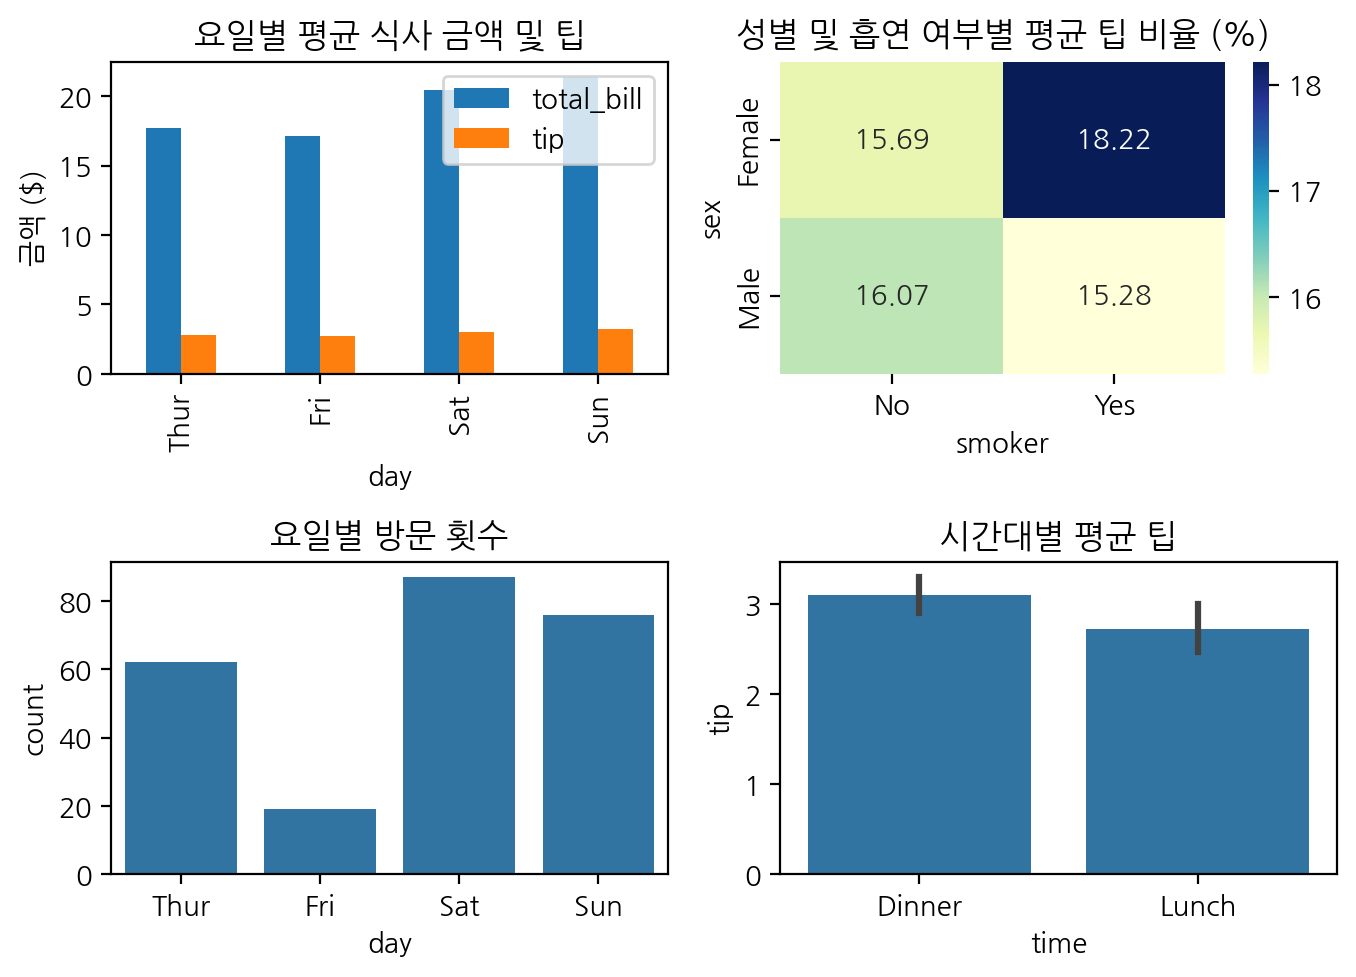

In [ ]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

# 그래프 1: 요일별 평균 식사 금액 및 팁
day_analysis.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('요일별 평균 식사 금액 및 팁')
axes[0, 0].set_ylabel('금액 ($)')

# 그래프 2: 성별/흡연여부별 평균 팁 비율
sns.heatmap(sex_smoker_analysis, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0, 1])
axes[0, 1].set_title('성별 및 흡연 여부별 평균 팁 비율 (%)')

# 그래프 3: 요일별 방문 횟수 (데이터 분포 확인)
sns.countplot(data=tips, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'], ax=axes[1, 0])
axes[1, 0].set_title('요일별 방문 횟수')

# 그래프 4: 시간대별 평균 팁
sns.barplot(data=tips, x='time', y='tip', ax=axes[1, 1])
axes[1, 1].set_title('시간대별 평균 팁')

plt.tight_layout()
plt.savefig('tips_analysis.png')

### 종료